# Exercise - SAR Prediction in VHP Head Model (2)

Exercise in the lecture Machine Learning in Electrical Engineering and Information Technology, Prediction of the Specific Absorption Rate (SAR)

* Lecture Period: Summer 2026 ([StudIP](https://e-learning.tuhh.de/studip/dispatch.php/course/details/index/1be148fc0ce85172e3902adf814a909b))
* Institute: Institut für Theoretische Elektrotechnik ([TET](https://www.tet.tuhh.de/en/))
* University: Hamburg University of Technology ([TUHH](https://www.tuhh.de/tuhh/en/startpage))
* Exercise Supervisor: Malte Thode


The second part of the exercise is about the prediction of the Specific Absorption Rate (SAR) inside a human head model. The human head model consists of multiple tissues that vary in their electric properties.

|||
|:-:|:-:|
|<img title="head exposed to fields" src='figures/model8_2.PNG' width='500'/>|<img title="tissues of the human head model" src='figures/SAR_VHP.png' width='500'/>|
|**VHP Head Model**|**SAR Distribution using FEM Solver**|

### This notebook is structured as follows:
* Loading of required python modules, including a helper module
* Loading the data from the specified CSV file
* Choosing input and output features
* Scaling the data
* Training neural networks
* Evaluating neural networks 

### How to work with the notebook

Each section consists of 2 to 3 cells. The first cell is an introduction to the section and explains the behavior of the following cells. Settings or variables are set in the following cell. Make your settings as you want and run the cell. The cell after is a *code cell*. You do not need to make any settings here, just run the code.

|-|
|:-:|
|<img title="How to Work with the Notebook!" src='figures/cell_setup_2.png' width='700'/>|
|**How to work with the Notebook!**|

#### Module Import
**Modules** are imported, which have to be available to the python interpreter.  
**helper_functions (hp)** is a module in the working directory providing some functions making the notebook more tidy.

**Module Links for Further Information:**
* [pandas](https://pandas.pydata.org/)
* [numpy](https://numpy.org/)
* [matplotlib](https://matplotlib.org/)
* [pickle](https://docs.python.org/3/library/pickle.html)
* [scikit-learn](https://scikit-learn.org/stable/index.html)

In [1]:
# code cell
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, KFold
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from IPython.display import display, Markdown
from matplotlib import pyplot as plt
import sklearn.metrics as sm
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")


#### Load Data from Working Directory

From the local directory the CSV file is loaded. The electric properties of the different tissues are varied and given in the table. The ***conductivity*** and ***relative permitivitty*** of each tissue represent the ***input features***. The resulting ***SAR*** in the different tissues after simulation represent the ***output*** features.

All data samples are split in **Test** and **Train** data before any operations (scaling, ...) are performed.  

**Variables:**
* *test_size* &rarr; share of data used for testing the trained neural network
* *file_name* &rarr; file containing the data

In [2]:
# variables
file_name = "data/task_2.csv"
test_size = 0.20
random_state = 42


#### Data Display in Table
Read the above file and  display at least first five rows ( sample sets) of input features and outputs for all tissues.

In [3]:
# Load and inspect the complete FEM dataset.
data_set = pd.read_csv(file_name)

print("Dataset shape:", data_set.shape)
display(data_set.head())
print("All column names:")
print(data_set.columns.tolist())
print("Number of samples:", data_set.shape[0])
print("Number of input features:", 28)

assert data_set.shape == (500, 43), "The expected dataset shape is 500 x 43."


Dataset shape: (500, 43)


,Eps_blood,Eps_bodyAverage,Eps_boneCortical,Eps_brainGreyMatter,Eps_brainWhiteMatter,Eps_cartilage,Eps_cerebellum,Eps_cerebrospinalFluid,Eps_eyeVitrousHumor,Eps_fatAverageInfiltrated,...,SAR_cartilage(W/kG),SAR_cerebellum(W/kG),SAR_cerebrospinalFluid(W/kG),SAR_eyeVitrousHumor(W/kG),SAR_fatAverageInfiltrated(W/kG),SAR_nerve(W/kG),SAR_skin(W/kG),SAR_tongue(W/kG),SAR_tooth(W/kG),SAR_max(W/kG)
0,213.304441,137.340829,27.261918,248.374777,171.316061,128.622449,349.622381,92.623836,72.774791,27.869940,...,0.002212,0.000384,0.001849,0.000057,0.000446,0.000229,0.000401,0.000140,0.000007,0.002212
1,230.581074,120.815896,34.940186,225.366658,149.852035,130.371693,355.144636,114.894013,63.531107,24.301469,...,0.002563,0.000369,0.001866,0.000045,0.000435,0.000263,0.000398,0.000147,0.000009,0.002563
2,227.977126,126.028505,32.462032,228.303351,168.611134,139.595331,383.033851,105.327273,78.034323,28.728686,...,0.002019,0.000365,0.001804,0.000062,0.000424,0.000247,0.000362,0.000122,0.000009,0.002019
3,187.693142,130.005210,27.309981,246.363504,166.130195,146.474017,381.715258,103.740564,78.283802,28.668307,...,0.001767,0.000369,0.001791,0.000063,0.000406,0.000249,0.000359,0.000132,0.000007,0.001791
4,193.239816,125.495530,30.265481,252.820374,173.361470,150.386422,353.345159,93.888970,72.768746,22.408424,...,0.002030,0.000384,0.001765,0.000066,0.000453,0.000221,0.000379,0.000140,0.000008,0.002030


All column names:
['Eps_blood', 'Eps_bodyAverage', 'Eps_boneCortical', 'Eps_brainGreyMatter', 'Eps_brainWhiteMatter', 'Eps_cartilage', 'Eps_cerebellum', 'Eps_cerebrospinalFluid', 'Eps_eyeVitrousHumor', 'Eps_fatAverageInfiltrated', 'Eps_nerve', 'Eps_skin', 'Eps_tongue', 'Eps_tooth', 'Cond_blood(S/m)', 'Cond_bodyAverage(S/m)', 'Cond_boneCortical(S/m)', 'Cond_brainGreyMatter(S/m)', 'Cond_brainWhiteMatter(S/m)', 'Cond_cartilage(S/m)', 'Cond_cerebellum(S/m)', 'Cond_cerebrospinalFluid(S/m)', 'Cond_eyeVitrousHumor(S/m)', 'Cond_fatAverageInfiltrated(S/m)', 'Cond_nerve(S/m)', 'Cond_skin(S/m)', 'Cond_tongue(S/m)', 'Cond_tooth(S/m)', 'SAR_blood(W/kG)', 'SAR_bodyAverage(W/kG)', 'SAR_boneCortical(W/kG)', 'SAR_brainGreyMatter(W/kG)', 'SAR_brainWhiteMatter(W/kG)', 'SAR_cartilage(W/kG)', 'SAR_cerebellum(W/kG)', 'SAR_cerebrospinalFluid(W/kG)', 'SAR_eyeVitrousHumor(W/kG)', 'SAR_fatAverageInfiltrated(W/kG)', 'SAR_nerve(W/kG)', 'SAR_skin(W/kG)', 'SAR_tongue(W/kG)', 'SAR_tooth(W/kG)', 'SAR_max(W/kG)']
Numb

#### Choosing input and output features

From the loaded file, the input and output features have to be chosen. For this specific task, all the electric properties of the different tissues are to be selected as input. The SAR value of a single tissue is to be chosen as the output. The selection of the input features is carried out using indices because of the large number of features.
* *output_features* &rarr; columns of the data file used as output features

In [4]:
# Select one tissue SAR as the regression target (easy to change later).
target_tissue = "brainGreyMatter"
output_feature = f"SAR_{target_tissue}(W/kG)"

# Only the first 28 material-property columns are ANN inputs. No SAR columns enter X.
input_features = data_set.columns[:28].tolist()
X = data_set.loc[:, input_features].copy()

# Convert FEM ground truth from W/kg to mW/kg for physically interpretable errors.
y = data_set[output_feature].astype(float) * 1000.0
y.name = f"SAR_{target_tissue}(mW/kg)"

print("Selected output:", output_feature, "->", y.name)
print("Input shape:", X.shape)
print("Output shape:", y.shape)
assert X.shape[1] == 28 and not any(name.startswith("SAR_") for name in X.columns)


Selected output: SAR_brainGreyMatter(W/kG) -> SAR_brainGreyMatter(mW/kg)
Input shape: (500, 28)
Output shape: (500,)


#### Spilit Train and Test

Split the given samples into seperate parts to be used for train and test 

In [5]:
# Shuffle and split once. The test set remains untouched during model selection.
train_input, test_input, train_output, test_output = train_test_split(
    X,
    y,
    test_size=test_size,
    random_state=random_state,
    shuffle=True,
)

print("Training samples:", len(train_input))
print("Test samples:", len(test_input))
print("Input features:", train_input.shape[1])


Training samples: 400
Test samples: 100
Input features: 28


#### Scaling of Data
A scaler is used to scale the input features. The scaler is fitted on the train data only, and applied to the train and test data. Feature scaling usually makes the training faster. It prevents the optimization from getting stuck in local optima.

In [6]:
# Fit preprocessing only on training inputs to avoid data leakage.
scaler = StandardScaler()
scaler.fit(train_input)

train_input_scaled = scaler.transform(train_input)
test_input_scaled = scaler.transform(test_input)


#### Training Neural Networks

**Sklearn** provides methods to train different kind of machine learning tools e.g. neural networks. To predict the SAR values inside the sphere, we have to define a regressor. The topology and training parameters of the neural network are defined and set before train.

**Variables:**
* *hidden_layer_sizes* &rarr; topologies of neural networks
* *solver* &rarr; solver used during training the neural network and optimizing the weights
* *learning_rate_init* &rarr; initial learning rates used for the solver
* *learning_rate* &rarr; type of learning rate
* *max_iter* &rarr; maximum number of iterations before termination of the training 
* *activation* &rarr; activation function for the hidden layer.
* *alpha* &rarr; strength of the L2 regularization term. 
* *n_iter_no_change* &rarr; maximum number of epochs to not meet tol improvement.
* *early_stopping* &rarr; Whether to use early stopping to terminate training when validation score is not improving

Possible parameters can be identified on https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html


In [7]:
# Baseline ANN configuration suggested in the exercise.
baseline_params = {
    "hidden_layer_sizes": (5,),
    "learning_rate_init": 1e-2,
    "solver": "adam",
    "max_iter": 20000,
    "activation": "tanh",
    "alpha": 0.0001,
    "n_iter_no_change": 50,
    "tol": 1e-5,
    "early_stopping": True,
    "random_state": random_state,
}

print("Baseline parameters:", baseline_params)


Baseline parameters: {'hidden_layer_sizes': (5,), 'learning_rate_init': 0.01, 'solver': 'adam', 'max_iter': 20000, 'activation': 'tanh', 'alpha': 0.0001, 'n_iter_no_change': 50, 'tol': 1e-05, 'early_stopping': True, 'random_state': 42}


#### Try New Variables 
Change the parameters for MLPRegressor and fit the Neural Network with new parameters as well.
Have you found a better parameter combination? 

In [8]:
# Compare configurations by cross-validation on training data only.
# A Pipeline refits StandardScaler inside every CV fold, preventing validation leakage.
cv = KFold(n_splits=5, shuffle=True, random_state=random_state)
baseline_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(**baseline_params)),
])
baseline_cv_scores = cross_val_score(
    baseline_pipeline, train_input, train_output, cv=cv, scoring="r2"
)

search_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        solver="adam",
        max_iter=20000,
        n_iter_no_change=50,
        tol=1e-5,
        early_stopping=True,
        random_state=random_state,
    )),
])
parameter_distributions = {
    "mlp__hidden_layer_sizes": [(5,), (10,), (20,), (10, 5), (20, 10)],
    "mlp__activation": ["tanh", "relu"],
    "mlp__alpha": [1e-5, 1e-4, 1e-3],
    "mlp__learning_rate_init": [1e-3, 1e-2],
}

# Twenty seeded combinations keep the search computationally reasonable.
search = RandomizedSearchCV(
    search_pipeline,
    param_distributions=parameter_distributions,
    n_iter=20,
    scoring="r2",
    cv=cv,
    random_state=random_state,
    n_jobs=-1,
    return_train_score=True,
)
search.fit(train_input, train_output)

best_params = {key.replace("mlp__", ""): value for key, value in search.best_params_.items()}
print("Baseline parameters:", baseline_params)
print("Best parameters:", best_params)
print(f"Baseline mean CV R2: {baseline_cv_scores.mean():.6f} +/- {baseline_cv_scores.std():.6f}")
print(f"Best mean CV R2:     {search.best_score_:.6f}")


Baseline parameters: {'hidden_layer_sizes': (5,), 'learning_rate_init': 0.01, 'solver': 'adam', 'max_iter': 20000, 'activation': 'tanh', 'alpha': 0.0001, 'n_iter_no_change': 50, 'tol': 1e-05, 'early_stopping': True, 'random_state': 42}
Best parameters: {'learning_rate_init': 0.001, 'hidden_layer_sizes': (5,), 'alpha': 1e-05, 'activation': 'tanh'}
Baseline mean CV R2: 0.907983 +/- 0.022328
Best mean CV R2:     0.937586


In [9]:
# Train the selected ANN once on all available training samples.
final_params = {
    "solver": "adam",
    "max_iter": 20000,
    "n_iter_no_change": 50,
    "tol": 1e-5,
    "early_stopping": True,
    "random_state": random_state,
    **best_params,
}
NN = MLPRegressor(**final_params)
NN.fit(train_input_scaled, train_output)

print("Final ANN topology:", NN.hidden_layer_sizes)
print("Iterations used:", NN.n_iter_)


Final ANN topology: (5,)
Iterations used: 4543


#### Predict the Results
Predict the output feature using the Neural Network

In [10]:
# The untouched test inputs are used now, after model selection is complete.
train_pred = NN.predict(train_input_scaled)
NN_pred = NN.predict(test_input_scaled)


#### Evaluating Neural Network Training

After training the neural networks, the networks are evaluated. There are many different metrics to evaluate the performance of the neural network including scores and errors (mean squared error, mean absolute error, ...). Plots of the loss curve and prediction of the test samples give a better insight on the performance.

* *Training and testing scores* &rarr; coefficient of determination R² that measures how well a statistical model predicts an outcome.
* *Mean absolute error* &rarr; average of the absolute errors between predictions and actual values.
* *Mean squared error* &rarr; average of the squares of the errors between predictions and actual values.
* *Median absolute error* &rarr; median of the absolute errors between predictions and actual values.
* *explained variance score* &rarr; measure of the dispersion of errors.
* *most widely used correlation* &rarr; coefficient to measure a linear correlation.

More informations on metrics and scoring on https://scikit-learn.org/stable/modules/model_evaluation.html#model-evaluation

In [11]:
# Final scores and errors (SAR errors are in mW/kg).
r2_train = sm.r2_score(train_output, train_pred)
r2_test = sm.r2_score(test_output, NN_pred)
mae = sm.mean_absolute_error(test_output, NN_pred)
mse = sm.mean_squared_error(test_output, NN_pred)
medae = sm.median_absolute_error(test_output, NN_pred)
explained_variance = sm.explained_variance_score(test_output, NN_pred)
pearson_corr, pearson_p = pearsonr(test_output.to_numpy(), NN_pred)

print(f"R2_train:              {r2_train:.6f}")
print(f"R2_test:               {r2_test:.6f}")
print(f"MAE (mW/kg):           {mae:.6f}")
print(f"MSE ((mW/kg)^2):       {mse:.6f}")
print(f"Median AE (mW/kg):     {medae:.6f}")
print(f"Explained variance:    {explained_variance:.6f}")
print(f"Pearson correlation:   {pearson_corr:.6f} (p={pearson_p:.3e})")

r2_gap = r2_train - r2_test
if r2_gap > 0.10:
    overfit_statement = f"There is an appreciable train-test R2 gap ({r2_gap:.3f}), suggesting overfitting."
else:
    overfit_statement = f"There is no obvious severe overfitting; the train-test R2 gap is {r2_gap:.3f}."
print(overfit_statement)


R2_train:              0.990983
R2_test:               0.885673
MAE (mW/kg):           0.001579
MSE ((mW/kg)^2):       0.000016
Median AE (mW/kg):     0.000843
Explained variance:    0.887298
Pearson correlation:   0.945511 (p=1.482e-49)
There is an appreciable train-test R2 gap (0.105), suggesting overfitting.


#### Plot the evaluation results
Plot the MSE and also the predicted vs. actual value of SAR.

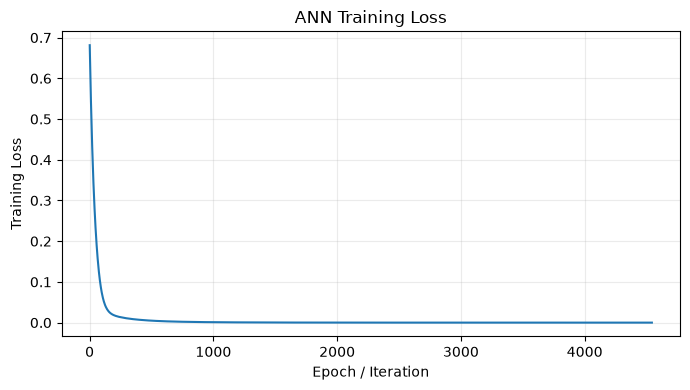

In [12]:
# loss_curve_ is the ANN's training loss, not test MSE.
plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(NN.loss_curve_) + 1), NN.loss_curve_, color="tab:blue")
plt.xlabel("Epoch / Iteration")
plt.ylabel("Training Loss")
plt.title("ANN Training Loss")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


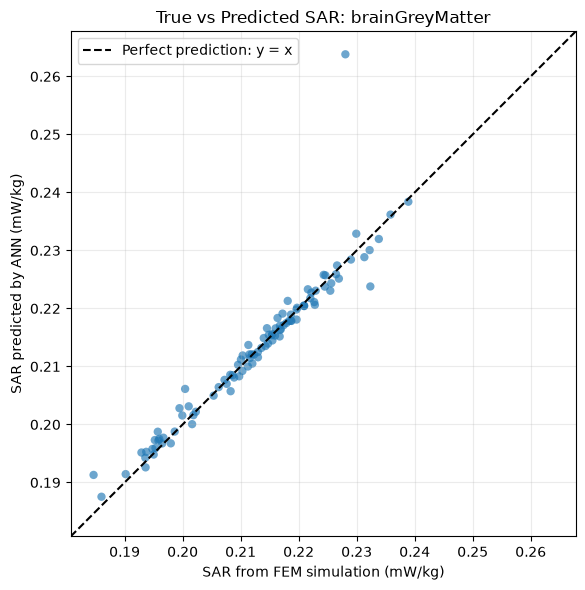

In [13]:
# FEM ground truth versus ANN prediction.
plot_min = min(float(test_output.min()), float(NN_pred.min()))
plot_max = max(float(test_output.max()), float(NN_pred.max()))
padding = 0.05 * (plot_max - plot_min)
limits = (plot_min - padding, plot_max + padding)

plt.figure(figsize=(6, 6))
plt.scatter(test_output, NN_pred, alpha=0.65, edgecolor="none")
plt.plot(limits, limits, "k--", label="Perfect prediction: y = x")
plt.xlim(limits)
plt.ylim(limits)
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("SAR from FEM simulation (mW/kg)")
plt.ylabel("SAR predicted by ANN (mW/kg)")
plt.title(f"True vs Predicted SAR: {target_tissue}")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


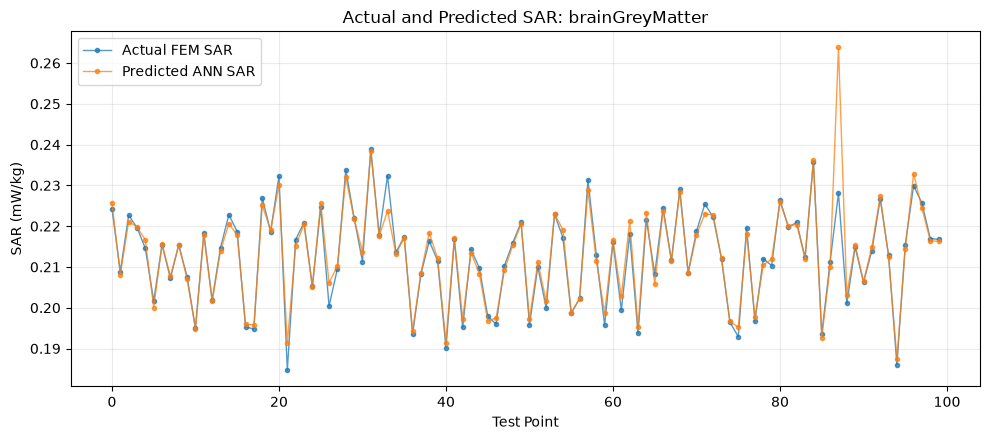

In [14]:
# Direct comparison at every test point.
test_points = np.arange(len(test_output))
plt.figure(figsize=(10, 4.5))
plt.plot(test_points, test_output.to_numpy(), "o-", markersize=3, linewidth=1,
         label="Actual FEM SAR", alpha=0.75)
plt.plot(test_points, NN_pred, "o-", markersize=3, linewidth=1,
         label="Predicted ANN SAR", alpha=0.75)
plt.xlabel("Test Point")
plt.ylabel("SAR (mW/kg)")
plt.title(f"Actual and Predicted SAR: {target_tissue}")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


#### Guiding Questions

The following cells implement permutation sensitivity, a reduced-feature check, and concise answers based on the measured results.


#### Sensitivity Analysis

Permutation importance measures the decrease in predictive score when one input is shuffled. It describes this ANN's predictive dependence, not physical causality. Feature ranking is calculated on the training set so that the test set is not used for feature selection.


,Feature,Importance,Std
0,Cond_brainGreyMatter(S/m),0.982024,0.049350
1,Cond_cerebrospinalFluid(S/m),0.776805,0.040961
2,Eps_brainGreyMatter,0.113444,0.005334
3,Cond_bodyAverage(S/m),0.085125,0.008416
4,Cond_brainWhiteMatter(S/m),0.081381,0.008951
5,Cond_cartilage(S/m),0.081138,0.015771
6,Cond_tooth(S/m),0.072726,0.012586
7,Cond_fatAverageInfiltrated(S/m),0.063611,0.007866
8,Cond_blood(S/m),0.062253,0.007441
9,Cond_boneCortical(S/m),0.062148,0.005832


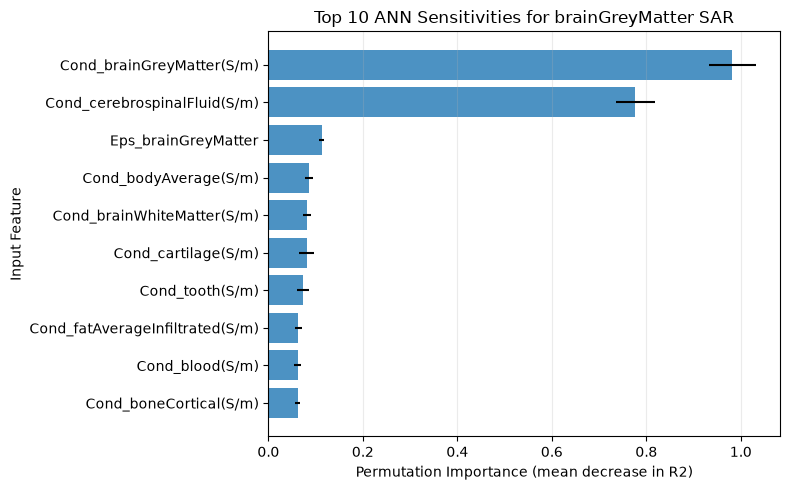

In [15]:
# Training-set permutation importance for feature ranking.
permutation_result = permutation_importance(
    NN,
    train_input_scaled,
    train_output,
    scoring="r2",
    n_repeats=30,
    random_state=random_state,
    n_jobs=-1,
)
importance_table = pd.DataFrame({
    "Feature": input_features,
    "Importance": permutation_result.importances_mean,
    "Std": permutation_result.importances_std,
}).sort_values("Importance", ascending=False, ignore_index=True)

top_10_importance = importance_table.head(10)
display(top_10_importance.style.format({"Importance": "{:.6f}", "Std": "{:.6f}"}))

plt.figure(figsize=(8, 5))
plot_data = top_10_importance.sort_values("Importance")
plt.barh(plot_data["Feature"], plot_data["Importance"], xerr=plot_data["Std"], alpha=0.8)
plt.xlabel("Permutation Importance (mean decrease in R2)")
plt.ylabel("Input Feature")
plt.title(f"Top 10 ANN Sensitivities for {target_tissue} SAR")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()


#### Reduced-Feature Experiment

The feature count is fixed in advance at 10. The ranking uses training data only; it is not chosen by looking at test performance. The same selected ANN hyperparameters are then fitted using those inputs.


In [16]:
n_reduced_features = 10
reduced_features = importance_table.head(n_reduced_features)["Feature"].tolist()

reduced_scaler = StandardScaler()
reduced_train_scaled = reduced_scaler.fit_transform(train_input[reduced_features])
reduced_test_scaled = reduced_scaler.transform(test_input[reduced_features])

reduced_NN = MLPRegressor(**final_params)
reduced_NN.fit(reduced_train_scaled, train_output)
reduced_pred = reduced_NN.predict(reduced_test_scaled)

comparison = pd.DataFrame({
    "Model": ["All 28 inputs", f"Top {n_reduced_features} training-ranked inputs"],
    "R2_test": [r2_test, sm.r2_score(test_output, reduced_pred)],
    "MAE_mW_per_kg": [mae, sm.mean_absolute_error(test_output, reduced_pred)],
    "MSE_(mW_per_kg)^2": [mse, sm.mean_squared_error(test_output, reduced_pred)],
})
display(comparison.style.format({
    "R2_test": "{:.6f}",
    "MAE_mW_per_kg": "{:.6f}",
    "MSE_(mW_per_kg)^2": "{:.6f}",
}))
print("Reduced features:", reduced_features)


,Model,R2_test,MAE_mW_per_kg,MSE_(mW_per_kg)^2
0,All 28 inputs,0.885673,0.001579,0.000016
1,Top 10 training-ranked inputs,0.596444,0.004378,0.000056


Reduced features: ['Cond_brainGreyMatter(S/m)', 'Cond_cerebrospinalFluid(S/m)', 'Eps_brainGreyMatter', 'Cond_bodyAverage(S/m)', 'Cond_brainWhiteMatter(S/m)', 'Cond_cartilage(S/m)', 'Cond_tooth(S/m)', 'Cond_fatAverageInfiltrated(S/m)', 'Cond_blood(S/m)', 'Cond_boneCortical(S/m)']


#### Answers to the Guiding Questions and Final Summary


In [17]:
reduced_r2 = comparison.loc[1, "R2_test"]
reduced_mae = comparison.loc[1, "MAE_mW_per_kg"]
top_five = importance_table.head(5)["Feature"].tolist()

if reduced_r2 >= r2_test - 0.02 and reduced_mae <= mae * 1.10:
    feature_conclusion = (
        f"The fixed top-{n_reduced_features} model retained similar performance, so all 28 inputs "
        "were not necessary for this split."
    )
else:
    feature_conclusion = (
        f"The fixed top-{n_reduced_features} model lost noticeable performance, so retaining all 28 "
        "inputs was beneficial for this split."
    )

answers = f"""
**Do we need a neural network?**  
Not necessarily. Over the +/-20% material-property variation, the mapping may be smooth or close to linear. An ANN is nevertheless useful as a fast nonlinear surrogate for expensive FEM simulations.

**What alternatives could be used?**  
Linear regression, polynomial regression, random-forest regression, support-vector regression, and Gaussian-process regression are reasonable alternatives.

**Do we need scaling?**  
Scaling is recommended for an MLP because the 28 properties have different numerical ranges and gradient-based optimization works better with comparable feature scales. Here the scaler was fitted only on training inputs.

**Do we need all 28 inputs?**  
{feature_conclusion} The measured all-input and reduced-input results are shown above.

**What is the effect of other tissues' properties?**  
The five strongest predictive dependencies were {', '.join(top_five)}. Properties of other tissues can alter the internal electromagnetic-field distribution and thus the SAR in {target_tissue}. Permutation importance describes model dependence and does not establish physical causality.

**Does data splitting affect evaluation?**  
Yes. With 500 samples, different splits can change scores. `random_state=42` makes this split reproducible, while five-fold training-only cross-validation provides a more robust basis for model selection.

**How was sensitivity analysis implemented?**  
Each standardized training feature was repeatedly shuffled while the fitted ANN was held fixed. The resulting mean decrease in R2 is its permutation importance.

### Compact Final Summary

| Item | Result |
|---|---|
| Number of samples | {len(X)} |
| Train/test sizes | {len(train_input)} / {len(test_input)} |
| Input dimension | {train_input.shape[1]} |
| Selected output | {y.name} |
| ANN topology | {NN.hidden_layer_sizes} |
| Best hyperparameters | {best_params} |
| R2_train | {r2_train:.6f} |
| R2_test | {r2_test:.6f} |
| MAE | {mae:.6f} mW/kg |
| MSE | {mse:.6f} (mW/kg)^2 |
| MedAE | {medae:.6f} mW/kg |
| Explained Variance | {explained_variance:.6f} |
| Pearson correlation | {pearson_corr:.6f} |
| Top five sensitive inputs | {', '.join(top_five)} |
| Overfitting check | {overfit_statement} |
| Conclusion | {feature_conclusion} |
"""
display(Markdown(answers))



**Do we need a neural network?**  
Not necessarily. Over the +/-20% material-property variation, the mapping may be smooth or close to linear. An ANN is nevertheless useful as a fast nonlinear surrogate for expensive FEM simulations.

**What alternatives could be used?**  
Linear regression, polynomial regression, random-forest regression, support-vector regression, and Gaussian-process regression are reasonable alternatives.

**Do we need scaling?**  
Scaling is recommended for an MLP because the 28 properties have different numerical ranges and gradient-based optimization works better with comparable feature scales. Here the scaler was fitted only on training inputs.

**Do we need all 28 inputs?**  
The fixed top-10 model lost noticeable performance, so retaining all 28 inputs was beneficial for this split. The measured all-input and reduced-input results are shown above.

**What is the effect of other tissues' properties?**  
The five strongest predictive dependencies were Cond_brainGreyMatter(S/m), Cond_cerebrospinalFluid(S/m), Eps_brainGreyMatter, Cond_bodyAverage(S/m), Cond_brainWhiteMatter(S/m). Properties of other tissues can alter the internal electromagnetic-field distribution and thus the SAR in brainGreyMatter. Permutation importance describes model dependence and does not establish physical causality.

**Does data splitting affect evaluation?**  
Yes. With 500 samples, different splits can change scores. `random_state=42` makes this split reproducible, while five-fold training-only cross-validation provides a more robust basis for model selection.

**How was sensitivity analysis implemented?**  
Each standardized training feature was repeatedly shuffled while the fitted ANN was held fixed. The resulting mean decrease in R2 is its permutation importance.

### Compact Final Summary

| Item | Result |
|---|---|
| Number of samples | 500 |
| Train/test sizes | 400 / 100 |
| Input dimension | 28 |
| Selected output | SAR_brainGreyMatter(mW/kg) |
| ANN topology | (5,) |
| Best hyperparameters | {'learning_rate_init': 0.001, 'hidden_layer_sizes': (5,), 'alpha': 1e-05, 'activation': 'tanh'} |
| R2_train | 0.990983 |
| R2_test | 0.885673 |
| MAE | 0.001579 mW/kg |
| MSE | 0.000016 (mW/kg)^2 |
| MedAE | 0.000843 mW/kg |
| Explained Variance | 0.887298 |
| Pearson correlation | 0.945511 |
| Top five sensitive inputs | Cond_brainGreyMatter(S/m), Cond_cerebrospinalFluid(S/m), Eps_brainGreyMatter, Cond_bodyAverage(S/m), Cond_brainWhiteMatter(S/m) |
| Overfitting check | There is an appreciable train-test R2 gap (0.105), suggesting overfitting. |
| Conclusion | The fixed top-10 model lost noticeable performance, so retaining all 28 inputs was beneficial for this split. |
